In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad  # Добавлено для получения точных значений

In [3]:
def integrate_rectangles_right_tabulated(y_arr, h_val):
    # I ≈ h * Σ f(x_i) для i от 1 до n
    return h_val * np.sum(y_arr[1:])

In [4]:
def integrate_trapezoids_tabulated(y_arr, h_val):
    # I ≈ h * [ (f_0 + f_n)/2 + Σ f_i ]
    return h_val * (np.sum(y_arr) - 0.5 * (y_arr[0] + y_arr[-1]))

In [5]:
def integrate_simpson_tabulated(y_arr, h_val):
    # Формула Симпсона (парабол). Требует нечетного числа узлов.
    n_nodes = len(y_arr)
    if n_nodes % 2 == 0:
        return None
    
    # Формируем вектор весов: [1, 4, 2, 4, ..., 1]
    weights_vec = np.ones(n_nodes)
    weights_vec[1:-1:2] = 4
    weights_vec[2:-2:2] = 2
    
    return (h_val / 3) * np.sum(weights_vec * y_arr)

In [6]:
def integrate_trapezoids(func, a, b, h_val):
    """
    Интегрирование функции методом трапеций на [a, b] с шагом h.
    I ≈ h * [ (f(a) + f(b))/2 + Σ f(x_i) ]
    """
    n_steps = int(np.round((b - a) / h_val))
    x_vec = np.linspace(a, b, n_steps + 1)
    y_vec = func(x_vec)
    return integrate_trapezoids_tabulated(y_vec, h_val)

In [7]:
def integrate_rectangles(func, a, b, h):
    """
    I ≈ h * Σ f(x_i) для i от 1 до n
    """
    num_steps = int((b - a) / h)
    x_nodes = np.linspace(a, b, num_steps + 1)
    
    # Пересчитываем точный шаг (он может незначительно отличаться из-за округления num_steps)
    actual_h = (b - a) / num_steps
    
    y_values = func(x_nodes)
    
    return integrate_rectangles_right_tabulated(y_values, actual_h)

In [8]:
def integrate_simpson(func, a, b, h_val):
    """
    Интегрирование функции методом Симпсона на [a, b].
    Автоматически корректирует шаг для обеспечения четного количества отрезков.
    """
    n_steps = int(np.round((b - a) / h_val))
    if n_steps % 2 != 0:
        n_steps += 1
    
    actual_h = (b - a) / n_steps
    x_vec = np.linspace(a, b, n_steps + 1)
    y_vec = func(x_vec)
    return integrate_simpson_tabulated(y_vec, actual_h)

In [9]:
def integrate_gauss(func, a, b, n_points=4):
    """
    Квадратура Гаусса.
    I ≈ (b-a)/2 * Σ (A_i * f(x_i))
    """
    # Узлы и веса для интервала [-1, 1]
    nodes_map = {
        2: (np.array([-1/np.sqrt(3), 1/np.sqrt(3)]), np.array([1, 1])),
        3: (np.array([-np.sqrt(0.6), 0, np.sqrt(0.6)]), np.array([5/9, 8/9, 5/9])),
        4: (np.array([-0.861136, -0.339981, 0.339981, 0.861136]), 
            np.array([0.347855, 0.652145, 0.652145, 0.347855]))
    }
    t_vec, w_vec = nodes_map[n_points]
    
    # Линейное отображение на [a, b]
    x_nodes_vec = 0.5 * (b - a) * t_vec + 0.5 * (b + a)
    return 0.5 * (b - a) * np.sum(w_vec * func(x_nodes_vec))

# Задача 9.1. а

In [10]:
# Данные таблицы (а) для Симпсона: x от -1 до 1, h = 0.25
y_tab_a_arr = np.array([-1, -0.14, -0.032, 0.01, 0, 0.002, 0.003, 0.0031, 0.0029])
res_simpson_tab = integrate_simpson_tabulated(y_tab_a_arr, 0.25)

# Данные таблицы (б): x от 0 до 2, h = 0.25
y_tab_b_arr = np.array([0, 0.028, 0.054, 0.078, 0.1, 0.2, 0.133, 0.145, 0.154])
res_trapez_tab = integrate_trapezoids_tabulated(y_tab_b_arr, 0.25)
res_rect_right_tab = integrate_rectangles_right_tabulated(y_tab_b_arr, 0.25)

print(f"Табличные расчеты:")
print(f"  Симпсон: {res_simpson_tab:.6f}")
print(f"  Трапеции: {res_trapez_tab:.6f}")
print(f"  Правые прямоугольники: {res_rect_right_tab:.6f}")

Табличные расчеты:
  Симпсон: -0.129558
  Трапеции: 0.203750
  Правые прямоугольники: 0.223000


# 1. Несобственный интеграл (задача в): ∫ (1 - cos x) / (x * √x) dx от 0 до ∞

Особенность в 0 устранимая, т.к. (1-cos x) ~ x^2/2, предел функции в 0 равен 0.

In [11]:
def func_improper(x_vec):
    # Добавляем epsilon для численной стабильности
    return (1 - np.cos(x_vec)) / (x_vec * np.sqrt(x_vec) + 1e-15)

In [12]:
# Считаем на широком интервале
res_improper = integrate_simpson(func_improper, 1e-10, 100000.0, 0.01)
# Реальное значение через scipy.quad
res_improper_quad, _ = quad(func_improper, 0, np.inf)

C:\Users\Skif\AppData\Local\Temp\ipykernel_3540\2486882189.py:4: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  res_improper_quad, _ = quad(func_improper, 0, np.inf)


# 2. Быстроосциллирующая функция (задача б): ∫ cos(100x) * ln(x) dx от 1 до 2

In [13]:
def func_oscillating(x_vec):
    return np.cos(100 * x_vec) * np.log(x_vec)

In [14]:
# Для осцилляций нужен очень малый шаг h
res_osc = integrate_simpson(func_oscillating, 1, 2, 0.0005)
# Реальное значение через scipy.quad
res_osc_quad, _ = quad(func_oscillating, 1, 2)

print(f"\nСпецифические интегралы:")
print(f"  Несобственный (в): {res_improper:.6f} (Quad: {res_improper_quad:.6f})")
print(f"  Осциллирующий (б):  {res_osc:.6f} (Quad: {res_osc_quad:.6f})")


Специфические интегралы:
  Несобственный (в): 2.500263 (Quad: 2.511352)
  Осциллирующий (б):  -0.006115 (Quad: -0.006115)


In [15]:
np.sqrt(2*np.pi)

np.float64(2.5066282746310002)

# Анализ асимптотики погрешности #

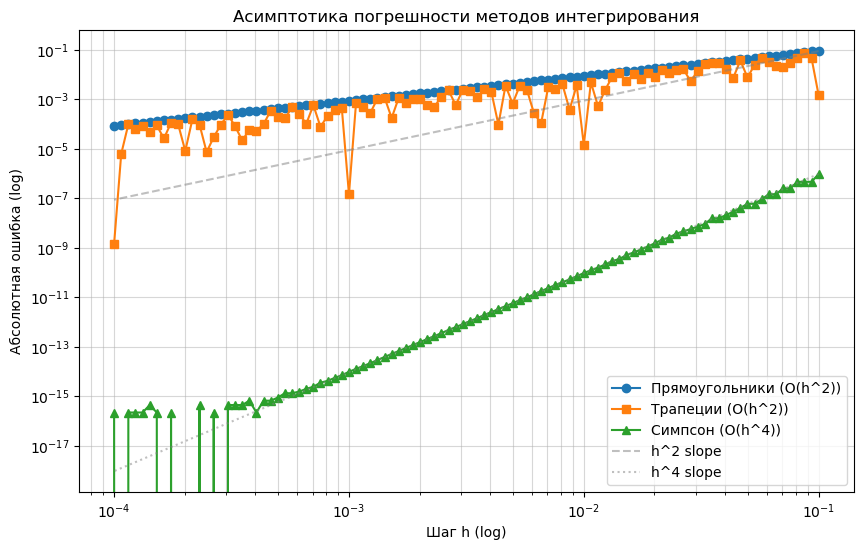

In [16]:
# Тестовая функция: exp(x), интеграл на [0, 1] равен e - 1
test_func = np.exp
a_lim, b_lim = 0, 1
exact_val = np.exp(1) - 1

# Набор шагов h для анализа
h_values = np.logspace(-1, -4, 100)
err_rect = []
err_trap = []
err_simp = []

for h in h_values:
    err_rect.append(abs(integrate_rectangles(test_func, a_lim, b_lim, h) - exact_val))
    err_trap.append(abs(integrate_trapezoids(test_func, a_lim, b_lim, h) - exact_val))
    err_simp.append(abs(integrate_simpson(test_func, a_lim, b_lim, h) - exact_val))

# Визуализация погрешностей
plt.figure(figsize=(10, 6))
plt.loglog(h_values, err_rect, '-o', label='Прямоугольники (O(h^2))')
plt.loglog(h_values, err_trap, '-s', label='Трапеции (O(h^2))')
plt.loglog(h_values, err_simp, '-^', label='Симпсон (O(h^4))')

# Опорные линии для визуализации порядка сходимости
plt.loglog(h_values, h_values**2 * err_rect[0]/h_values[0]**2, '--', color='gray', alpha=0.5, label='h^2 slope')
plt.loglog(h_values, h_values**4 * err_simp[0]/h_values[0]**4, ':', color='gray', alpha=0.5, label='h^4 slope')

plt.title('Асимптотика погрешности методов интегрирования')
plt.xlabel('Шаг h (log)')
plt.ylabel('Абсолютная ошибка (log)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()